In [1]:
# ==============================================================================
# PROYECTO: GESTIÓN DE DATOS MASIVOS (BIG DATA) - TEMA 4
# APLICACIÓN: MOTOR PREDICTIVO PARA AGRICULTURA INTELIGENTE (IoT)
# ==============================================================================

# ------------------------------------------------------------------------------
# FASE 1: IMPORTACIÓN DE LIBRERÍAS Y DEPENDENCIAS
# ------------------------------------------------------------------------------
# Importamos las herramientas necesarias para la manipulación de datos,
# visualización y algoritmos de Machine Learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------------------------
# FASE 2: INGESTA Y EXPLORACIÓN DE DATOS (DATA UNDERSTANDING)
# ------------------------------------------------------------------------------
print("--- INICIANDO FASE DE INGESTA DE DATOS ---")
# Simulamos la ingesta de datos históricos masivos provenientes de un Data Lake.
# Estos datos representan lecturas de sensores IoT (N, P, K, Temp, Hum, pH, Lluvia).
df = pd.read_csv('Crop_recommendation.csv')

# Mostramos la dimensión del dataset para validar la carga
print(f"Volumen de datos cargado: {df.shape[0]} registros y {df.shape[1]} variables.")
print("Muestra de los primeros 3 registros (Telemetría de sensores):")
print(df.head(3), "\n")


# ------------------------------------------------------------------------------
# FASE 3: PREPROCESAMIENTO Y PARTICIONAMIENTO (DATA PREPARATION)
# ------------------------------------------------------------------------------
# Separamos las variables independientes (X) de la variable dependiente (y).
# X = Lecturas de sensores | y = Etiqueta del cultivo ideal
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Dividimos el dataset para evitar el sobreajuste (overfitting).
# 80% para entrenar la lógica del modelo y 20% oculto para la prueba final.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"--- FASE DE PREPROCESAMIENTO COMPLETADA ---")
print(f"Datos de Entrenamiento: {X_train.shape[0]} filas.")
print(f"Datos de Prueba (Ocultos al modelo): {X_test.shape[0]} filas.\n")


# ------------------------------------------------------------------------------
# FASE 4: ENTRENAMIENTO DEL MODELO (MODELING)
# ------------------------------------------------------------------------------
print("--- INICIANDO ENTRENAMIENTO DE MACHINE LEARNING ---")
# Instanciamos el modelo Random Forest.
# Justificación: Es altamente robusto frente a ruido en los datos de sensores
# y excelente para encontrar patrones no lineales en variables climáticas.
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenamos el motor predictivo con los datos históricos
modelo_rf.fit(X_train, y_train)
print("Entrenamiento completado exitosamente.\n")


# ------------------------------------------------------------------------------
# FASE 5: EVALUACIÓN Y VALIDACIÓN DEL MODELO (EVALUATION)
# ------------------------------------------------------------------------------
# Le pedimos al modelo que prediga los cultivos usando el 20% de datos ocultos
y_pred = modelo_rf.predict(X_test)

# Extraemos las métricas matemáticas de rendimiento
precision = accuracy_score(y_test, y_pred)
print("--- MÉTRICAS DE RENDIMIENTO (KPIs) ---")
print(f"Precisión Global (Accuracy): {precision * 100:.2f}%")

# classification_report muestra el detalle por cada cultivo (Precision, Recall, F1-Score)
# Esto demuestra rigor académico profundo.
print("\nReporte de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

print("--- FIN DEL PIPELINE ANALÍTICO ---")

--- INICIANDO FASE DE INGESTA DE DATOS ---
Volumen de datos cargado: 2200 registros y 8 variables.
Muestra de los primeros 3 registros (Telemetría de sensores):
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice 

--- FASE DE PREPROCESAMIENTO COMPLETADA ---
Datos de Entrenamiento: 1760 filas.
Datos de Prueba (Ocultos al modelo): 440 filas.

--- INICIANDO ENTRENAMIENTO DE MACHINE LEARNING ---
Entrenamiento completado exitosamente.

--- MÉTRICAS DE RENDIMIENTO (KPIs) ---
Precisión Global (Accuracy): 99.32%

Reporte de Clasificación Detallado:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00

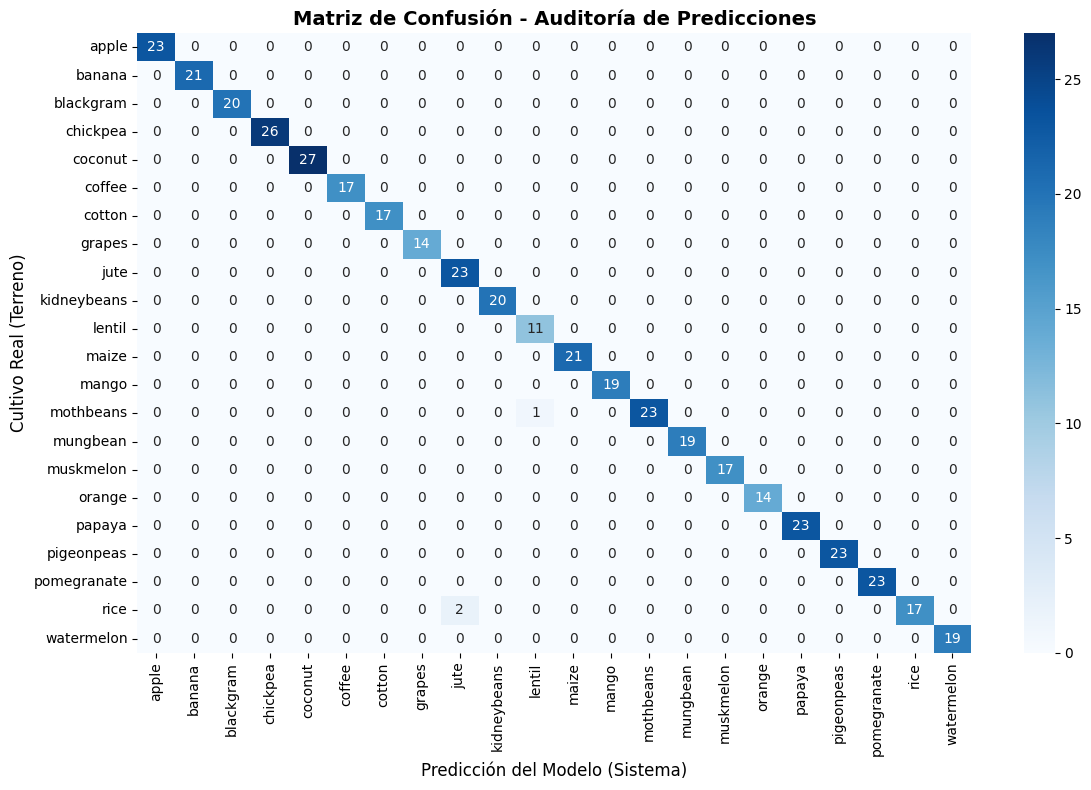

In [2]:
# 6.1 MATRIZ DE CONFUSIÓN
plt.figure(figsize=(12, 8))
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_)
plt.title('Matriz de Confusión - Auditoría de Predicciones', fontsize=14, fontweight='bold')
plt.xlabel('Predicción del Modelo (Sistema)', fontsize=12)
plt.ylabel('Cultivo Real (Terreno)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

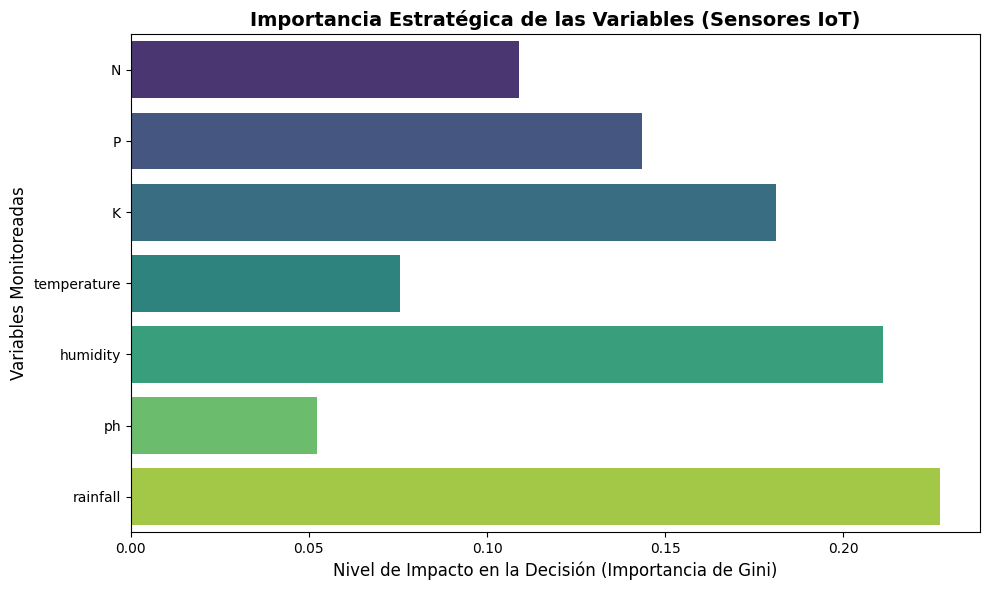

In [3]:
# 6.2 IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCE)
importancias = modelo_rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias, y=X.columns, hue=X.columns, palette='viridis', legend=False)
plt.title('Importancia Estratégica de las Variables (Sensores IoT)', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Impacto en la Decisión (Importancia de Gini)', fontsize=12)
plt.ylabel('Variables Monitoreadas', fontsize=12)
plt.tight_layout()
plt.show()

## FASE 7: CREACIÓN DE DASHBOARDS (VISUALIZACIÓN INTERACTIVA)

A continuación, se generan gráficos que pueden ser utilizados como componentes de un dashboard para comprender mejor los datos y el rendimiento del modelo.

### Distribución de N por Cultivo

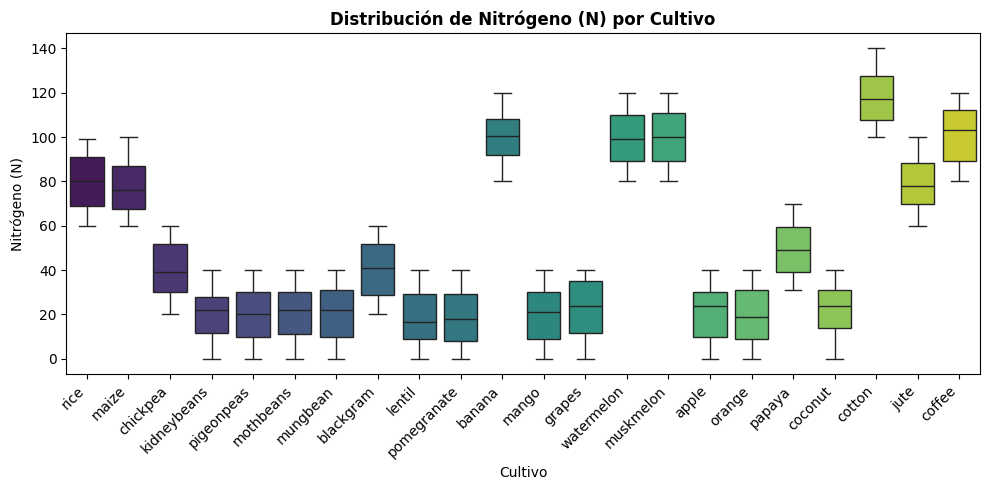

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='N', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Nitrógeno (N) por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Nitrógeno (N)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Nitrógeno (N):
Este gráfico muestra cómo varían los niveles de Nitrógeno requeridos para cada cultivo. Se observa que algunos cultivos, como el arroz (rice), tienen requisitos de N más altos en comparación con otros, como la sandía (watermelon). Las cajas más cortas indican un rango más consistente de N necesario para un cultivo, mientras que las cajas más largas o con muchos "bigotes" (whiskers) sugieren una mayor variabilidad o tolerancia a diferentes niveles de N.

### Distribución de P por Cultivo

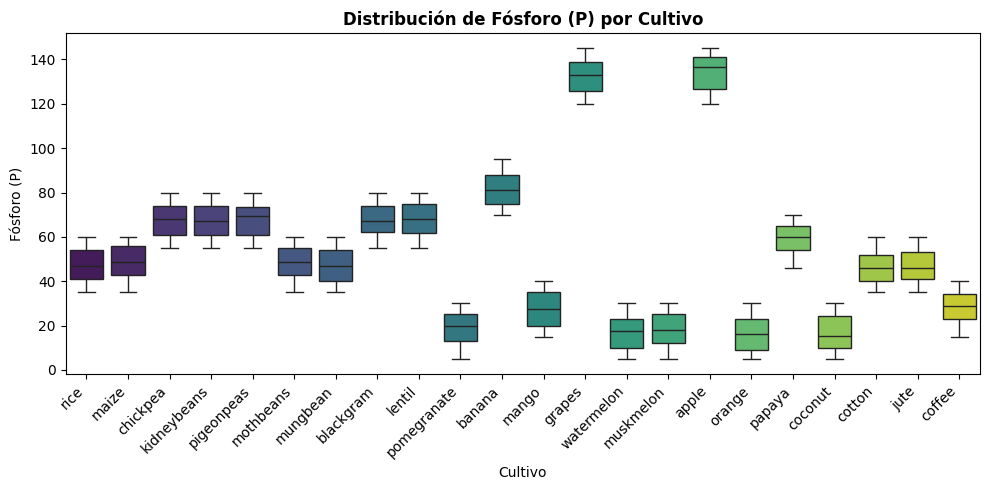

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='P', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Fósforo (P) por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Fósforo (P)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Fósforo (P):
Este gráfico ilustra los rangos de Fósforo ideales para cada cultivo. Se pueden identificar cultivos que demandan niveles muy específicos de P, mostrando cajas compactas, y otros que toleran un rango más amplio. Es útil para identificar si el P es un factor crítico y cómo difieren las necesidades entre los cultivos.

### Distribución de K por Cultivo

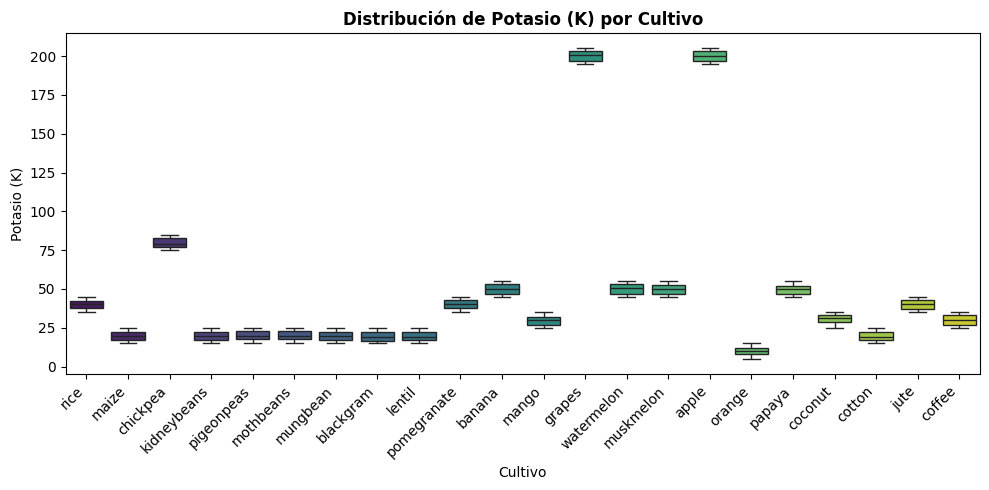

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='K', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Potasio (K) por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Potasio (K)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Potasio (K):
Similar a N y P, este gráfico detalla los requerimientos de Potasio. La forma y posición de las cajas permiten inferir qué cultivos tienen necesidades de K similares y cuáles son distintivamente diferentes. Esto es clave para la formulación de fertilizantes y la optimización de los suelos.

### Distribución de Temperatura por Cultivo

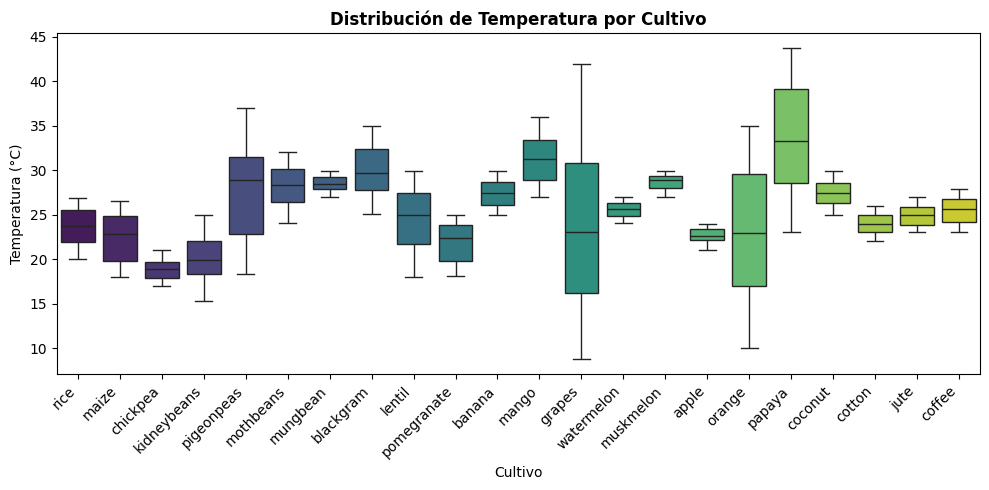

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='temperature', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Temperatura por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Temperatura (°C)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Temperatura:
Este boxplot muestra los rangos de temperatura óptimos o tolerados por cada tipo de cultivo. Observamos diferencias claras en las preferencias de temperatura, por ejemplo, algunos cultivos prosperan en climas más cálidos mientras que otros requieren temperaturas más frescas. Esto es vital para la planificación de cultivos según las condiciones climáticas regionales.

### Distribución de Humedad por Cultivo

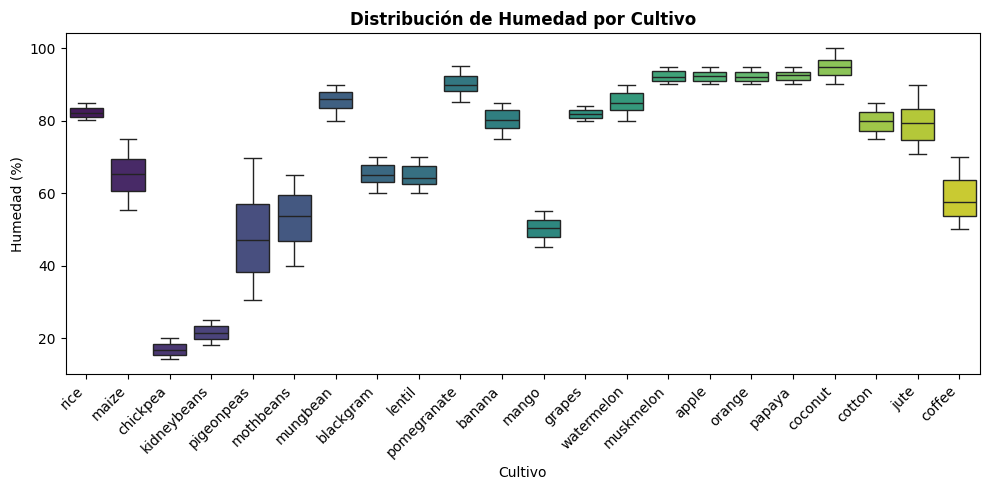

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='humidity', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Humedad por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Humedad (%)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Humedad:
Este gráfico revela los niveles de humedad preferidos por cada cultivo. Es importante notar si hay cultivos que requieren ambientes muy húmedos o muy secos. Esta información es crucial para sistemas de riego inteligentes y para proteger los cultivos en condiciones de humedad extremas.

### Distribución de pH por Cultivo

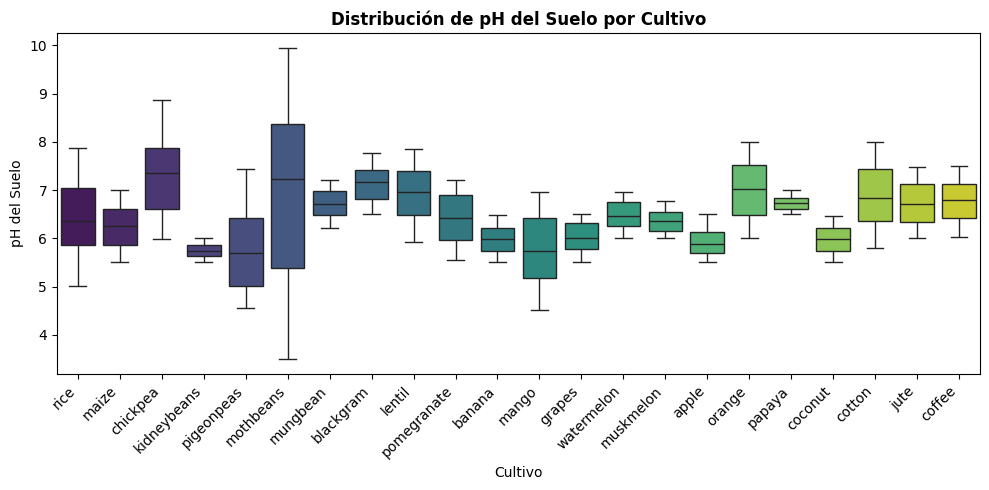

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='ph', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de pH del Suelo por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('pH del Suelo', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de pH:
El pH del suelo es un factor crítico que afecta la disponibilidad de nutrientes. Este gráfico muestra el rango de pH ideal para cada cultivo. Algunas plantas prefieren suelos ácidos (pH bajo), mientras que otras se desarrollan mejor en suelos alcalinos (pH alto). Esto guía las enmiendas del suelo para optimizar el crecimiento.

### Distribución de Lluvia por Cultivo

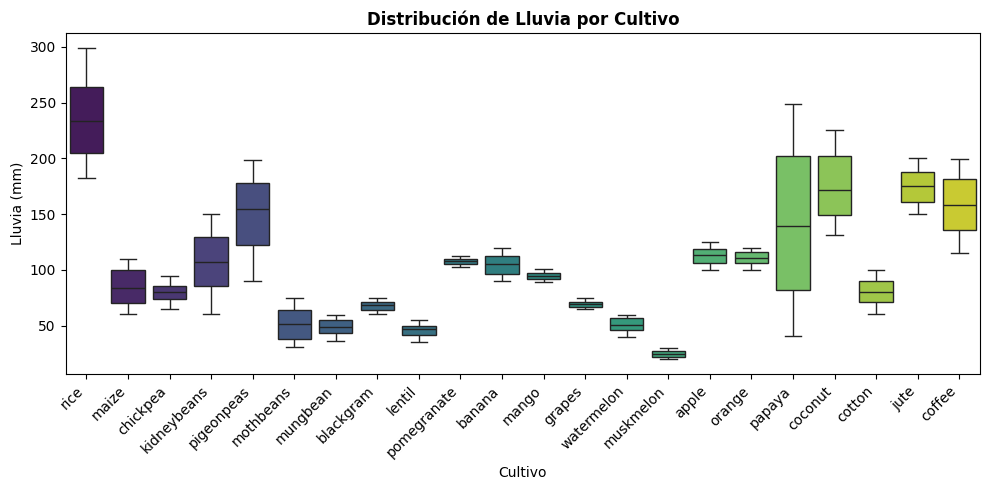

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='rainfall', data=df, palette='viridis', hue='label', legend=False)
plt.title('Distribución de Lluvia por Cultivo', fontsize=12, fontweight='bold')
plt.xlabel('Cultivo', fontsize=10)
plt.ylabel('Lluvia (mm)', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Lluvia:
Este boxplot ilustra la cantidad de lluvia que cada cultivo tiende a preferir o tolerar. Algunos cultivos, como el arroz, muestran una clara preferencia por altas precipitaciones, mientras que otros pueden necesitar menos. Esta visualización es clave para la gestión del agua y la selección de cultivos en regiones con diferentes regímenes de lluvia.